# Introduction

* Unsupervised learning is used to find patterns in dataset without labels.
* EX: Clustering, SVM, Dimentionality Reduction
* Lets get started with using IRIS dataset from Sklearn.


In [9]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
import mpl_toolkits.mplot3d 
import numpy as np

In [15]:

iris = datasets.load_iris()
X = iris.data
Y = iris.target

In [14]:
model = KMeans(n_clusters=3)
model.fit(X)


KMeans(n_clusters=3)

The below code shows KMeans clustering for more that one type of cluster.


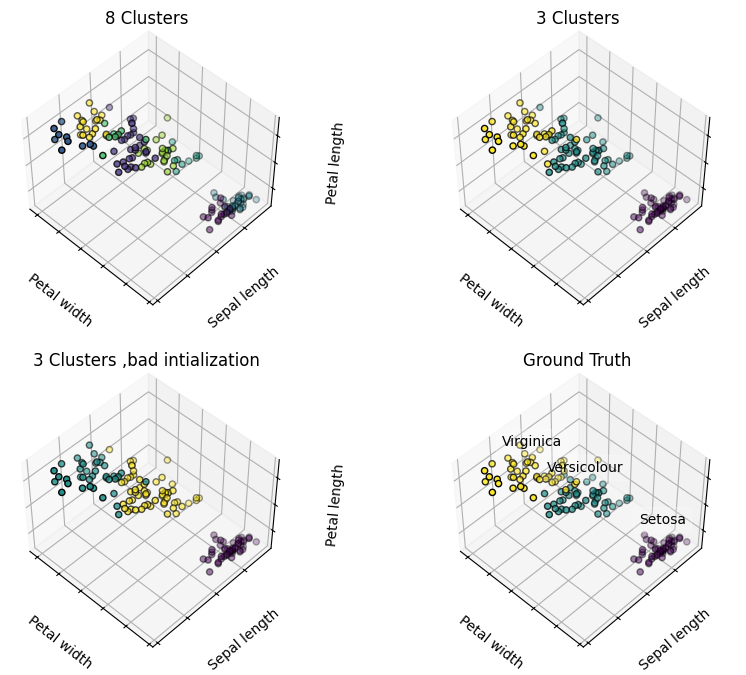

In [17]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
import mpl_toolkits.mplot3d 
import numpy as np

np.random.seed(5)

#Importing dataset and Assigning Labels and Targets
iris = datasets.load_iris()
X = iris.data
Y = iris.target


#N number of Kmeans
estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10,8))
titles = ["8 Clusters","3 Clusters","3 Clusters ,bad intialization"]
for idx, ((name,est), title)in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2,2,idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_
    ax.scatter(X[:,3],X[:,0],X[:,2],c=labels.astype(float),edgecolors="k")
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Petal width")
    ax.set_ylabel("Sepal length")
    ax.set_zlabel("Petal length")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(
        X[y == label, 3].mean(),
        X[y == label, 0].mean(),
        X[y == label, 2].mean() + 2,
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X[:, 3], X[:, 0], X[:, 2], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Petal width")
ax.set_ylabel("Sepal length")
ax.set_zlabel("Petal length")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

## Evalutaion of Clustering

* Check cluster correspondance
* Measure quality of Clustering
* We can use Cross tabluation from pandas that will help evaluate the correctness of the prediction.
*  Altough these give accuracy of predictions but fail to help us with how good our actually is.
*  A good cluster has tight clusters.
*  Samples in the clusters are bunched up together.
*  Measure of how spread out the clusters are can be done using Measure called Inertia.We can calculate it as follows


In [18]:
print(model.inertia_)

78.8556658259773


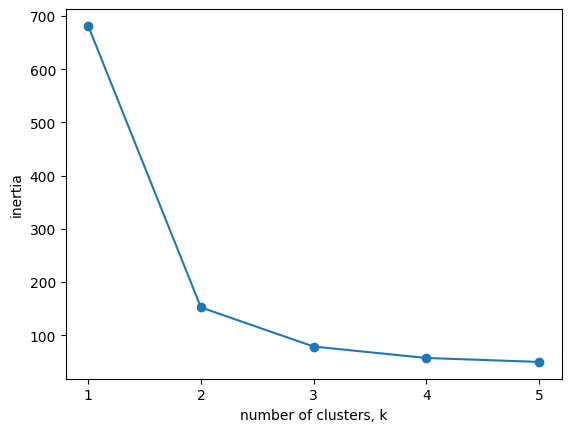

In [19]:
ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters=k)
    
    # Fit model to samples
    model.fit(X)
    
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)
    
# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()


### Evaluating the grain clustering

In [ ]:
import pandas as pd
# Create a KMeans model with 3 clusters: model
model = KMeans(n_clusters=3)

# Use fit_predict to fit model and obtain cluster labels: labels
labels = model.fit_predict(X)

# Create a DataFrame with clusters and varieties as columns: df
df = pd.DataFrame({'labels': labels, 'varieties': varieties})

# Create crosstab: ct
ct = pd.crosstab(df['labels'], df['varieties'])

# Display ct
print(ct)

## Clustering on Wine dataset

About the wine dataset:
 * 178 Samples from 3 distinct varities of red winde.
 * Features measures chemical composition eg alcohol content
 * Visual properties like "color intensity".
  

In [21]:
from sklearn.cluster import KMeans
import pandas as pd


df = pd.read_csv('data/Wine.csv')
df.head(10)

,class_label,class_name,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280,proline
0,1,Barolo,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,Barolo,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,Barolo,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,Barolo,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,Barolo,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,Barolo,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,Barolo,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,1,Barolo,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,1,Barolo,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,1,Barolo,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [23]:
X = df[['class_label']]
Y = df[['class_name']]

model = KMeans(n_clusters=3)
model.fit(X)

df = pd.DataFrame({'labels':labels,'varities':varities})
ct = pd.crosstab(df['labels'],df['varities'])
print(ct)

NameError: name 'varities' is not defined